In [28]:
import warnings
from typing import Dict, List, Any, Callable

import matplotlib.pyplot as plt
import numpy as np
from rsklpr.kernels import tricube_normalized_metric, laplacian_normalized_metric
from scipy.linalg import LinAlgWarning
from sklearn.model_selection import GridSearchCV

from grclpr.experiments.california_housing_exp1.california_housling_exp_1 import (
    load_california_housing_dataset,
    cv_linear,
    cv_knn,
    cv_poly_ridge,
    cv_rsklpr,
    haversine_rbf_kernel_factory,
    cv_gclpr_geo,
    display_model_results,
)

# Matplotlib setup
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
x_train, x_test, y_train, y_test = load_california_housing_dataset()

📥 Loading and preparing California Housing dataset...
Data prepared: 16512 training samples, 4128 testing samples.
Features: ['MedInc', 'AveRooms', 'Latitude', 'Longitude']


In [4]:
cv: int = 10
n_jobs: int = -1

In [5]:
knn_param_grid: Dict[str, List[Any]] = {
    "n_neighbors": list(range(3, 50, 2)),
    "weights": ["uniform", "distance"],
    "p": [1, 2],
    "leaf_size": [15, 30, 60],  # this mostly affects speed, not results
}

results_knn: GridSearchCV = cv_knn(
    x_train=x_train,
    y_train=y_train,
    param_grid=knn_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_knn.best_params_

🔎 Grid searching K-Nearest Neighbors... (CV)


{'leaf_size': 15, 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}

In [6]:
linear_param_grid: Dict[str, List[Any]] = {
    "fit_intercept": [True, False],
    "positive": [False, True],  # enforce non-negative coefficients
}

results_linear: GridSearchCV = cv_linear(
    x_train=x_train,
    y_train=y_train,
    param_grid=linear_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_linear.best_params_

🔎 Grid searching Global Linear... (CV)


{'fit_intercept': True, 'positive': False}

In [35]:
# For cv_poly_ridge (using Ridge)
param_grid_poly_ridge = {
    "poly__degree": [2, 3],
    "poly__interaction_only": [False, True],
    "ridge__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", LinAlgWarning)
    results_poly_ridge: GridSearchCV = cv_poly_ridge(
        x_train=x_train,
        y_train=y_train,
        param_grid=param_grid_poly_ridge,
        cv=cv,
        n_jobs=n_jobs,
    )

results_poly_ridge.best_params_

🔎 Grid searching Quadratic (Polynomial + Ridge)...


{'poly__degree': 2, 'poly__interaction_only': False, 'ridge__alpha': 0.1}

In [10]:
lpr_param_grid: List[Dict[str, Any]] = [
    # --- Grid 1: Testing Minkowski metric (p=1 and p=2) ---
    {
        "size_neighborhood": list(range(7, 301, 10)),
        "degree": [0, 1],
        "kp": [laplacian_normalized_metric, tricube_normalized_metric],  # Base kernels
        "metric_x": ["minkowski"],
        "metric_x_params": [{"p": 1}, {"p": 2}],
        "kr": ["none"],  # standard LPR
    },
    # --- Grid 2: Testing Mahalanobis metric ---
    {
        "size_neighborhood": list(range(7, 301, 10)),
        "degree": [0, 1],
        "kp": [laplacian_normalized_metric, tricube_normalized_metric],  # Base kernels
        "metric_x": ["mahalanobis"],
        "metric_x_params": [None],  # Mahalanobis takes no params
        "kr": ["none"],  # standard LPR
    },
]

results_lpr: GridSearchCV = cv_rsklpr(
    x_train=x_train,
    y_train=y_train,
    param_grid=lpr_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_lpr.best_params_

🔎 Grid searching LPR (Standard)... (CV)


{'degree': 1,
 'kp': <function rsklpr.kernels.tricube_normalized_metric(_: numpy.ndarray, __: numpy.ndarray, u: numpy.ndarray, ___: int, ____: numpy.ndarray) -> numpy.ndarray>,
 'kr': 'none',
 'metric_x': 'minkowski',
 'metric_x_params': {'p': 1},
 'size_neighborhood': 57}

In [23]:
rsklpr_param_grid: List[Dict[str, Any]] = [
    # --- Grid 1: Testing Minkowski metric (p=1 and p=2) ---
    {
        "size_neighborhood": list(range(7, 301, 10)),
        "degree": [0, 1],
        "kp": [laplacian_normalized_metric, tricube_normalized_metric],  # Base kernels
        "metric_x": ["minkowski"],
        "metric_x_params": [{"p": 1}, {"p": 2}],
        "kr": ["conden", "joint"],  # standard LPR
    },
    # --- Grid 2: Testing Mahalanobis metric ---
    {
        "size_neighborhood": list(range(7, 301, 10)),
        "degree": [0, 1],
        "kp": [laplacian_normalized_metric, tricube_normalized_metric],  # Base kernels
        "metric_x": ["mahalanobis"],
        "metric_x_params": [None],  # Mahalanobis takes no params
        "kr": ["conden", "joint"],  # standard LPR
    },
]

results_rsklpr: GridSearchCV = cv_rsklpr(
    x_train=x_train,
    y_train=y_train,
    param_grid=rsklpr_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_rsklpr.best_params_

🔎 Grid searching LPR (Standard)... (CV)


{'degree': 1,
 'kp': <function rsklpr.kernels.tricube_normalized_metric(_: numpy.ndarray, __: numpy.ndarray, u: numpy.ndarray, ___: int, ____: numpy.ndarray) -> numpy.ndarray>,
 'kr': 'joint',
 'metric_x': 'minkowski',
 'metric_x_params': {'p': 1},
 'size_neighborhood': 57}

In [13]:
# 1. Define the base kernels you want to test
base_kernels_to_test: List[
    Callable[[np.ndarray, np.ndarray, np.ndarray, int, np.ndarray], np.ndarray]
] = [laplacian_normalized_metric, tricube_normalized_metric]

# 2. Define the geospatial kernel length scales to test (in km)
geo_scales_km: List[float] = [5.0, 10.0, 15.0, 25.0, 50.0]

# 3. Create the list of kernel combinations
# This will be the value for the 'kp' key in our grid
geo_kp_lists: List[
    List[Callable[[np.ndarray, np.ndarray, np.ndarray, int, np.ndarray], np.ndarray]]
] = []

base_kernel: Callable[[np.ndarray, np.ndarray, np.ndarray, int, np.ndarray], np.ndarray]

for base_kernel in base_kernels_to_test:
    scale: float

    for scale in geo_scales_km:
        geo_kp_lists.append(
            [base_kernel, haversine_rbf_kernel_factory(length_scale_km=scale)]
        )


gclpr_geo_param_grid: List[Dict[str, Any]] = [
    # --- Grid 1: Testing Minkowski metric (p=1 and p=2) ---
    {
        "size_neighborhood": list(range(7, 301, 10)),
        "degree": [0, 1],
        "kp": geo_kp_lists,  # Use the lists we generated above
        "metric_x": ["minkowski"],
        "metric_x_params": [{"p": 1}, {"p": 2}],
        "kr": ["none"],
    },
    # --- Grid 2: Testing Mahalanobis metric ---
    {
        "size_neighborhood": list(range(7, 301, 10)),
        "degree": [0, 1],
        "kp": geo_kp_lists,  # Use the same kernel lists
        "metric_x": ["mahalanobis"],
        "metric_x_params": [None],  # Mahalanobis takes no params
        "kr": ["none"],
    },
]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)

    results_gclpr_geo: GridSearchCV = cv_gclpr_geo(
        x_train=x_train,
        y_train=y_train,
        param_grid=gclpr_geo_param_grid,
        cv=cv,
        n_jobs=n_jobs,
    )

results_gclpr_geo.best_params_

🔎 Grid searching GRC-LPR (Geospatial)... (CV)


{'degree': 1,
 'kp': [<function rsklpr.kernels.laplacian_normalized_metric(_: numpy.ndarray, __: numpy.ndarray, u: numpy.ndarray, ___: int, ____: numpy.ndarray) -> numpy.ndarray>,
  <function grclpr.california_housling_exp_1.haversine_rbf_kernel_factory.<locals>.<lambda>(x0, xn, d, x0_index, indices)>],
 'kr': 'none',
 'metric_x': 'minkowski',
 'metric_x_params': {'p': 1},
 'size_neighborhood': 117}



--- 📊 Evaluating models on Test Set ---

--- Evaluating: knn ---
Best CV Params: {'leaf_size': 15, 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Best CV Score (neg_mean_squared_error): -0.3022
✅ Test Set Evaluation: (RMSE: 0.5553 | R²: 0.7647)

--- Evaluating: linear ---
Best CV Params: {'fit_intercept': True, 'positive': False}
Best CV Score (neg_mean_squared_error): -0.5513
✅ Test Set Evaluation: (RMSE: 0.7486 | R²: 0.5724)

--- Evaluating: poly_ridge ---
Best CV Params: {'poly__degree': 2, 'poly__interaction_only': False, 'ridge__alpha': 0.1}
Best CV Score (neg_mean_squared_error): -0.5177
✅ Test Set Evaluation: (RMSE: 0.7351 | R²: 0.5876)

--- Evaluating: lpr ---
Best CV Params: {'degree': 1, 'kp': <function tricube_normalized_metric at 0x759ffc467420>, 'kr': 'none', 'metric_x': 'minkowski', 'metric_x_params': {'p': 1}, 'size_neighborhood': 57}
Best CV Score (neg_mean_squared_error): -0.2890
✅ Test Set Evaluation: (RMSE: 0.5278 | R²: 0.7874)

--- Evaluating: rsklpr ---
Best C

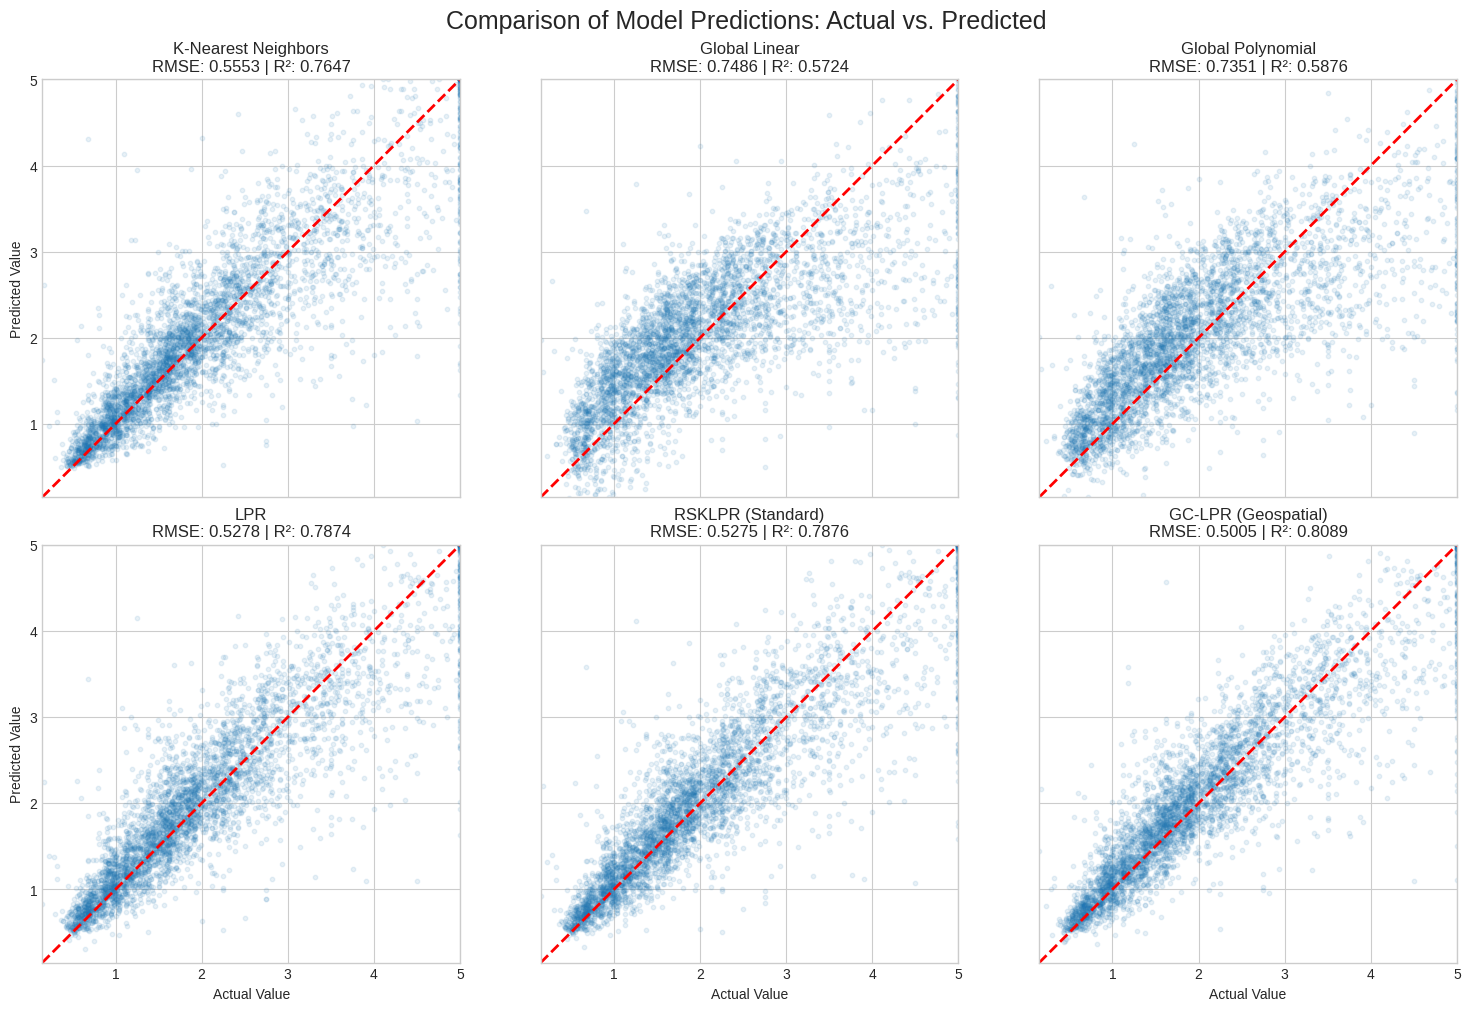

🗺️ Plotting geospatial error maps...


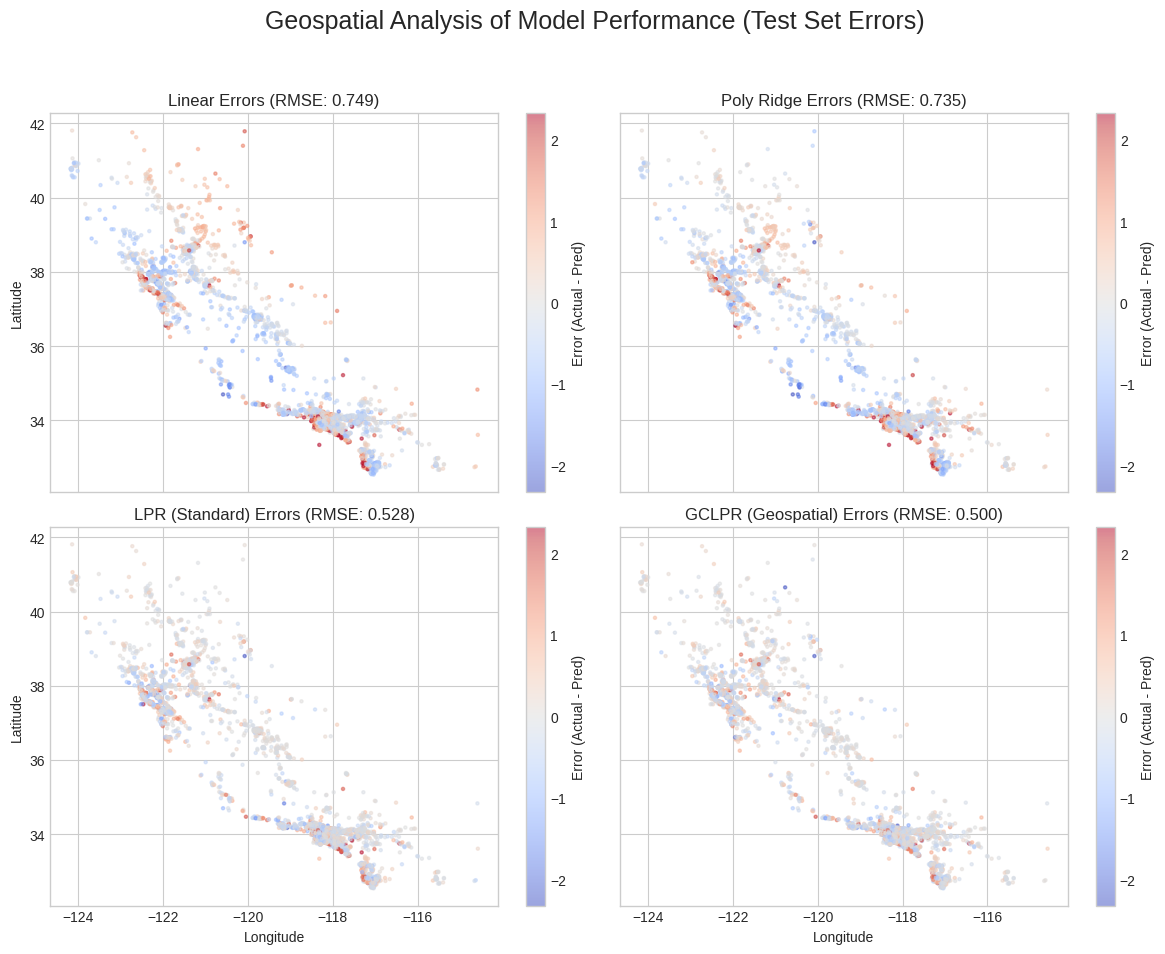

In [32]:
display_model_results(
    grid_search_results={
        "knn": results_knn,
        "linear": results_linear,
        "poly_ridge": results_poly_ridge,
        "lpr": results_lpr,
        "rsklpr": results_rsklpr,
        "gclpr_geo": results_gclpr_geo,
    },
    x_test=x_test,
    y_test=y_test,
)